In [1]:
import os
import ga_graphs as gg
from gmod import *
import numpy as np
import pandas as pd
import configparser
# plotting specifications
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.cm import ScalarMappable
from cycler import cycler
import seaborn as sns
mpl.rcParams.update({'font.size': 14})
plt.rcParams['axes.axisbelow'] = True
%matplotlib widget
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.linewidth'] = 2
#mpl.rcParams['axes.prop_cycle'] = cycler(color='bgrkmyc')
pd.set_option('display.max_columns', None)

# Comparison of solutions with and without imposed center-symmetry for XX Hamiltonians

This notebook compares the effect on solutions given by imposing the center symmetry condition for obtained couplings.

In [6]:
experiment_results = {}
column_names = ['dimension', 'delta', 'fidelity', 'time', 'generations']
data_statistics = pd.DataFrame(columns= ['dimension', 'smooth solution', 'reflect couplings', 'nsamples' ,'mean_fidelity', 'max_fidelity', 'min_fidelity', 'std_fidelity'])
best_solutions = {}

for dir in os.listdir('center-symmetry-experiments'):
    if dir.startswith('n'):
        dirname = 'center-symmetry-experiments/' + dir
        data = pd.read_csv(dirname + '/nvsmaxfid.dat', delim_whitespace=True, names=column_names)
        experiment_results[dir] = data

        for file in os.listdir(dirname):
            if file.endswith('.ini'):
                config = configparser.ConfigParser()
                config.read(dirname + '/' + file)
                
                experiment_stats = {}
                experiment_stats['dimension'] = config.getint('system_parameters', 'n')
                experiment_stats['smooth solution'] = config.getboolean('ga_initialization', 'smooth_solution')
                experiment_stats['reflect couplings'] = config.getboolean('system_parameters', 'reflect_couplings') if config.has_option('system_parameters', 'reflect_couplings') else True
                experiment_stats['mean_fidelity'] = data['fidelity'].mean()
                experiment_stats['max_fidelity'] = data['fidelity'].max()
                experiment_stats['min_fidelity'] = data['fidelity'].min()
                experiment_stats['std_fidelity'] = data['fidelity'].std()
                experiment_stats['nsamples'] = len(data)
                data_statistics = data_statistics.append(experiment_stats, ignore_index=True)

        best_idx = data['fidelity'].idxmax()
        best_sol = dirname + f'/jn{config.getint("system_parameters", "n")}sample{best_idx}.dat'
        
        best_solutions[dir] = best_sol

print(data_statistics.sort_values(by='dimension'))

   dimension smooth solution reflect couplings nsamples  mean_fidelity  \
1         20            True              True       50       0.991877   
2         20           False              True       50       0.993005   
5         20           False             False       50       0.988846   
8         20            True             False       50       0.991325   
0         30            True              True       50       0.992425   
3         30            True             False       50       0.991069   
10        30           False             False       50       0.984838   
11        30           False              True       50       0.993088   
4         40            True              True       50       0.991734   
6         40           False              True       50       0.992421   
7         40            True             False       50       0.990954   
9         40           False             False       50       0.984099   

    max_fidelity  min_fidelity  std_f

We can then use the ga_graphs module to plot some features of the solutions. For example, to plot the first and second solutions found we can use the ```plot_couplings``` function.

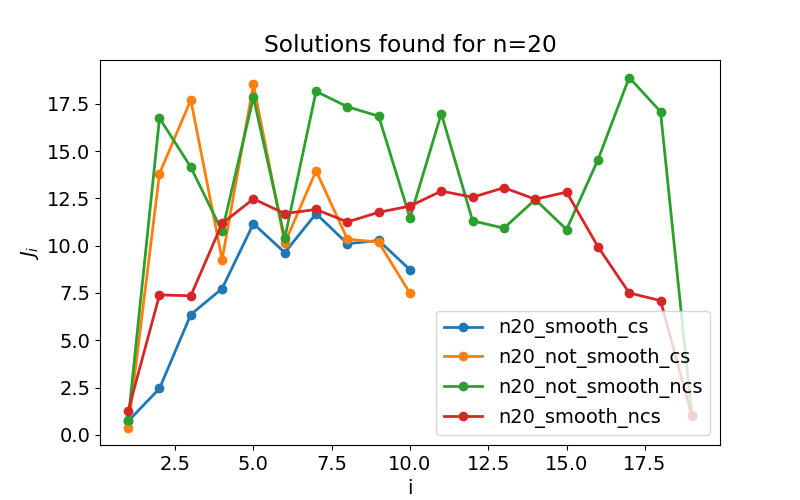

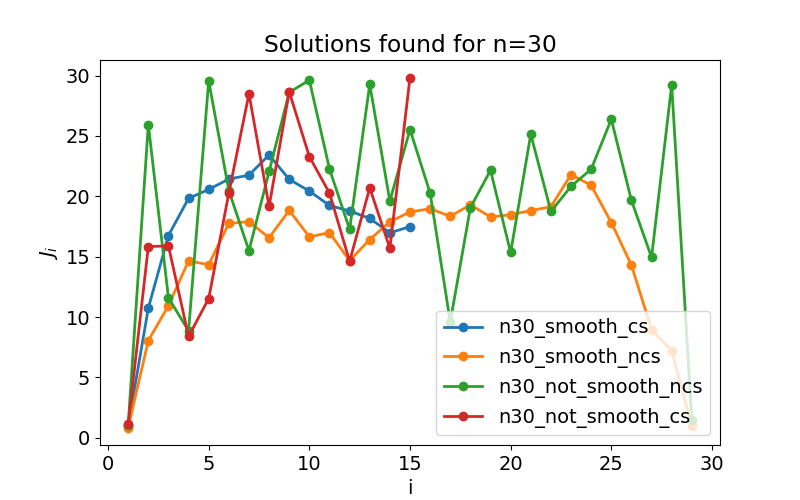

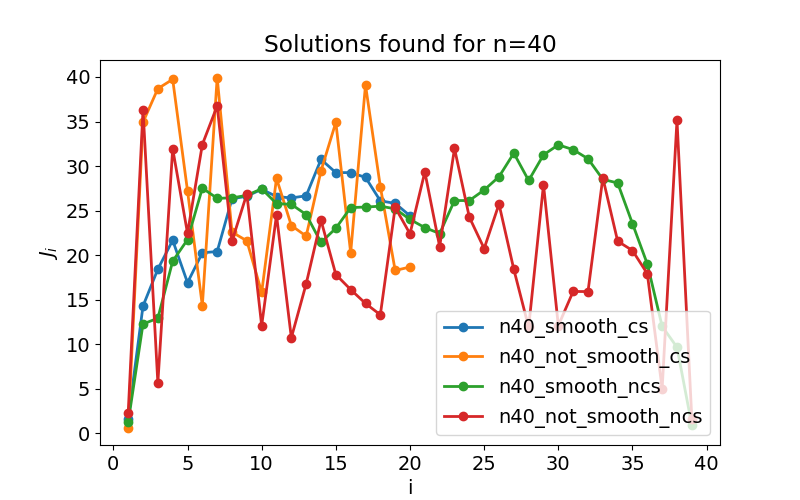

In [ ]:
file1 = 'fixed_dim/jn20sample0.dat'
file2 = 'fixed_dim/jn20sample1.dat'
dimensions = [20,30,40, 80, 100, 120]
keys = best_solutions.keys()
for dimension in dimensions:
    files = []
    labels = []
    for key in keys:
        if str(dimension) in key:
           files.append(best_solutions[key])
           labels.append(f'{key}')
    gg.plot_couplings(files, labels = labels, title = f'Solutions found for n={dimension}')

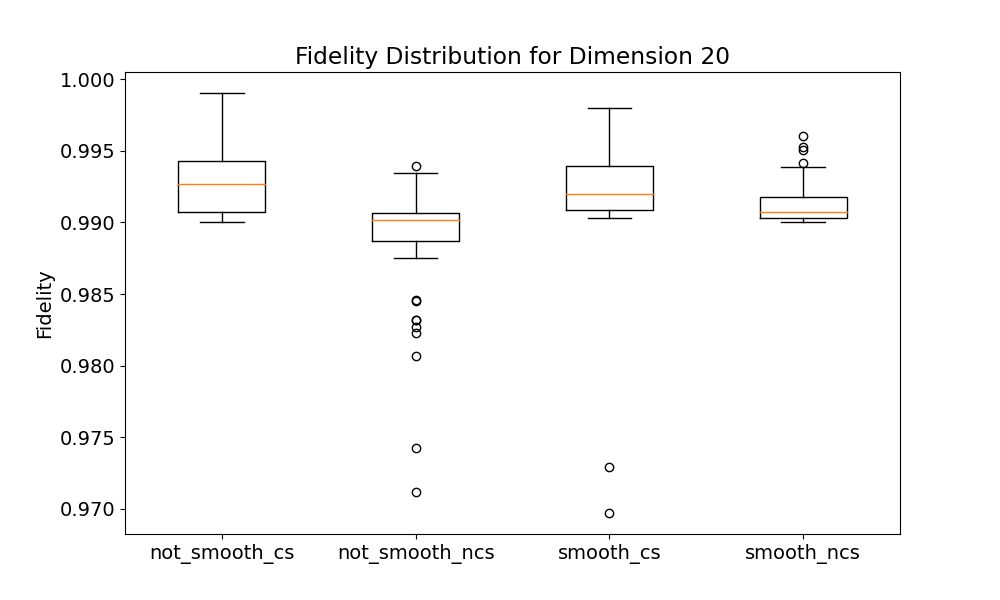

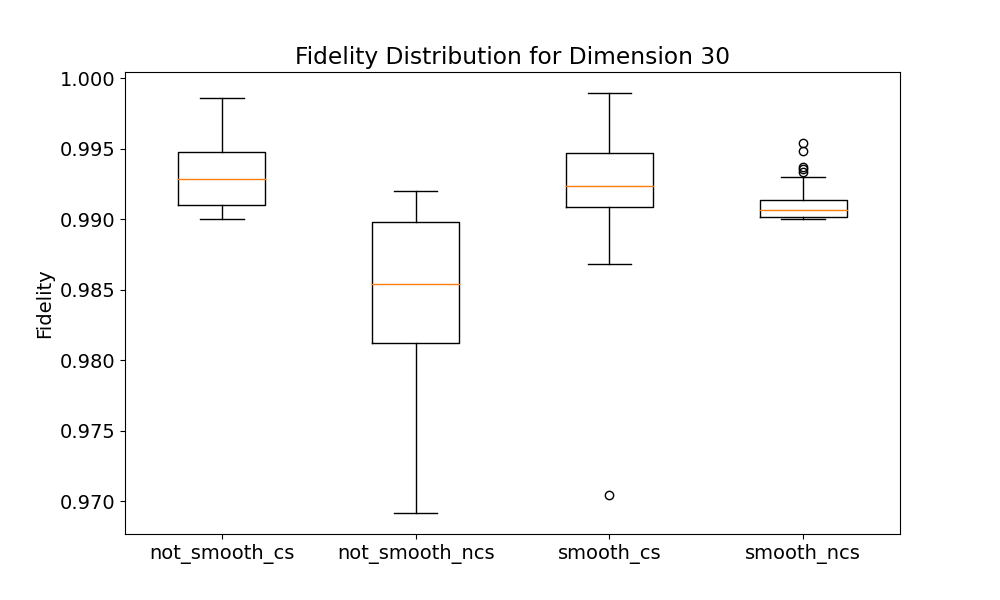

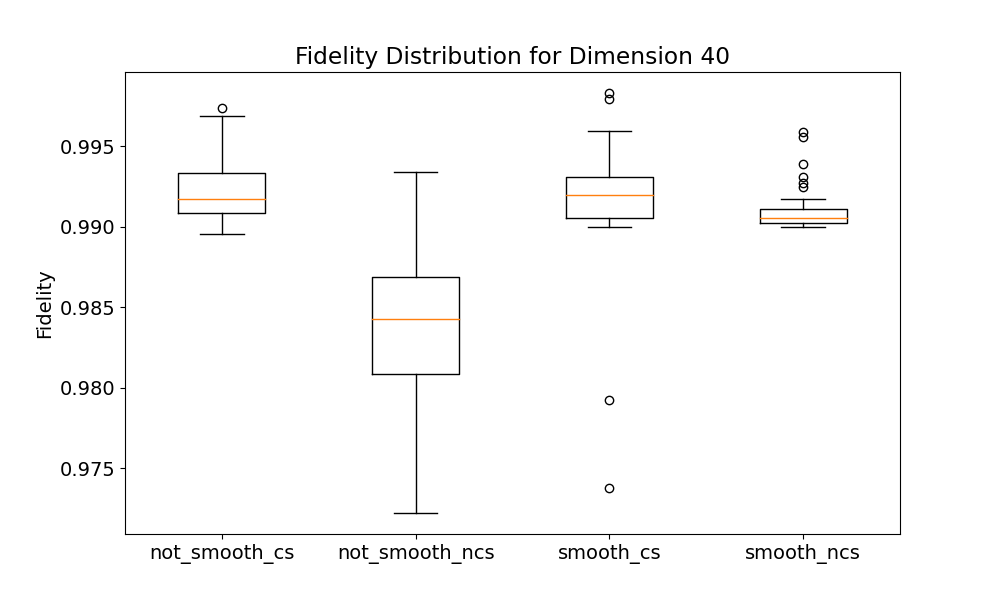

In [4]:
dimensions = [20,30,40]
experiment_results = {key: experiment_results[key] for key in sorted(experiment_results.keys())}

keys = experiment_results.keys()

for dim in dimensions:
    fixed_dim_dfs = []
    labels = []
    mean_fidelities = []
    max_fidelities = []
    for key in keys:
        if str(dim) in key: 
            df = experiment_results[key]
            fixed_dim_dfs.append(df)
            labels.append(key)
            mean_fidelity = np.mean(df['fidelity'])
            max_fidelity = np.max(df['fidelity'])
            mean_fidelities.append(mean_fidelity)
            max_fidelities.append(max_fidelity)
    
    plt.figure(figsize=(10,6))
    plt.boxplot([df['fidelity'] for df in fixed_dim_dfs], labels=[label[4:] for label in labels])
    plt.title('Fidelity Distribution for Dimension {}'.format(dim))
    plt.ylabel('Fidelity')
    plt.show()
